Data Overview
        Dataset Dimensions: 119,390 rows and 29 columns.
        Time Period Covered: 2017 to 2019.
        

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
arnings.simplefilter(action='ignore', category=FutureWarning)

In [49]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})


 STAGE 1: DATA PREPROCESSING


In [50]:
# 1. Load Data
df = pd.read_csv('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\hotel_bookings_data.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [51]:
# 2. Data Cleaning & Imputationabs
df['children'] = df['children'].fillna(0)
df['city'] = df['city'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,0.0,0.0,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,0.0,0.0,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,0.0,0.0,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,0.0,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,0.0,0,Personal,98.0,0,1,Check-Out


In [52]:
# Deduplication
df_clean = df.drop_duplicates().copy()

In [53]:
# Value Standardization
df_clean['meal'] = df_clean['meal'].replace('Undefined', 'No Meal')

In [ ]:
# Anomaly Filtering
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 5000)]
df_clean = df_clean[(df_clean['adults'] + df_clean['children'] + df_clean['babies']) > 0]

In [ ]:
# Feature Engineering
df_clean['total_stay'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_weekdays_nights']

In [87]:
# Save cleaned dataset
df_clean.to_csv('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\hotel_bookings_cleaned.csv', index=False)
print(f"Data Cleaning Complete. Remaining Rows: {len(df_clean)}")

Data Cleaning Complete. Remaining Rows: 85962



 STAGE 2: DATA ANALYSIS & VISUALIZATION


2.1 Share of Bookings & Monthly Trends

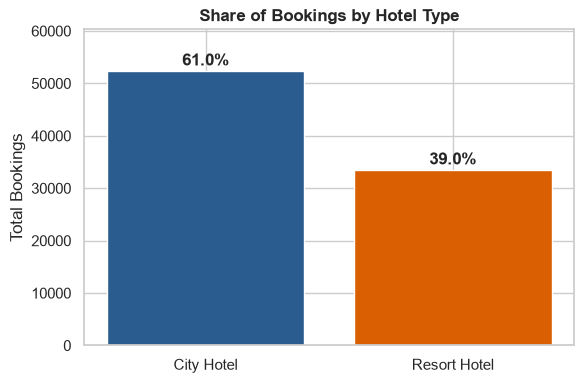

In [86]:
# Chart 1: Share of Bookings by Hotel Type
plt.figure(figsize=(6, 4))
hotel_counts = df_clean['hotel'].value_counts()
hotel_percentages = df_clean['hotel'].value_counts(normalize=True) * 100

bars = plt.bar(hotel_counts.index, hotel_counts.values, color=['#2b5c8f', '#d95f02'])
for bar, pct in zip(bars, hotel_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f"{pct:.1f}%", ha='center', fontweight='bold')

plt.title("Share of Bookings by Hotel Type", fontsize=12, fontweight='bold')
plt.ylabel("Total Bookings")
plt.ylim(0, max(hotel_counts.values) * 1.15)
plt.savefig('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart1_hotel_share.png', dpi=300)
plt.show()
plt.close()

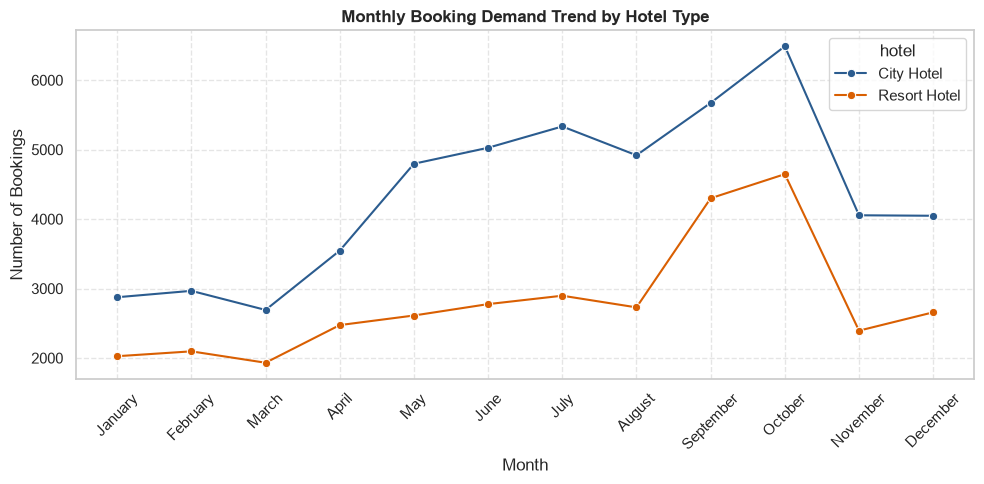

In [85]:
# Chart 2: Monthly Booking Trend
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_df = df_clean.groupby(['arrival_date_month', 'hotel'], observed=False).size().reset_index(name='count')
monthly_df['arrival_date_month'] = pd.Categorical(monthly_df['arrival_date_month'], categories=months_order, ordered=True)
monthly_df = monthly_df.sort_values('arrival_date_month')

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_df, x='arrival_date_month', y='count', hue='hotel', marker='o', palette=['#2b5c8f', '#d95f02'])
plt.xticks(rotation=45)
plt.title("Monthly Booking Demand Trend by Hotel Type", fontsize=12, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart2_monthly_bookings.png', dpi=300)
plt.show()
plt.close()

2.2 Impact of Stay Duration on Cancellation Rate

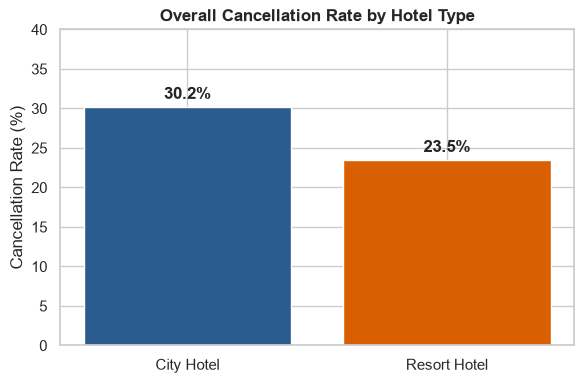

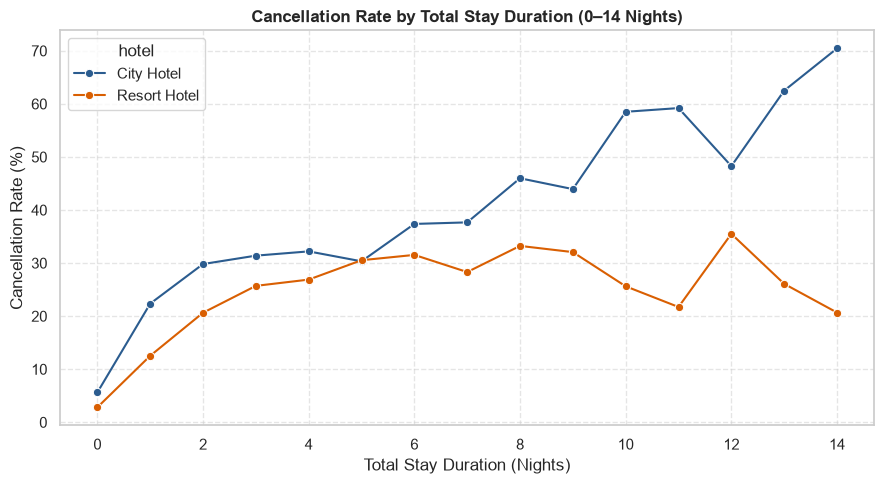

In [84]:
# Chart 3: Cancellation Rate by Hotel Type
cancel_rates = df_clean.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(cancel_rates.index, cancel_rates.values, color=['#2b5c8f', '#d95f02'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.1f}%", ha='center', fontweight='bold')

plt.title("Overall Cancellation Rate by Hotel Type", fontsize=12, fontweight='bold')
plt.ylabel("Cancellation Rate (%)")
plt.ylim(0, 40)
plt.savefig('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart3_cancellation_by_hotel.png', dpi=300)
plt.show()
plt.close()

# Chart 4: Stay Duration vs Cancellation Rate (0 to 14 Nights)
stay_df = df_clean[df_clean['total_stay'] <= 14].groupby(['total_stay', 'hotel'])['is_canceled'].mean().reset_index()
stay_df['cancellation_rate'] = stay_df['is_canceled'] * 100

plt.figure(figsize=(9, 5))
sns.lineplot(data=stay_df, x='total_stay', y='cancellation_rate', hue='hotel', marker='o', palette=['#2b5c8f', '#d95f02'])
plt.title("Cancellation Rate by Total Stay Duration (0–14 Nights)", fontsize=12, fontweight='bold')
plt.xlabel("Total Stay Duration (Nights)")
plt.ylabel("Cancellation Rate (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart4_stay_duration_cancellation.png', dpi=300)
plt.show()
plt.close()

2.3 Impact of Lead Time on Cancellation Rate

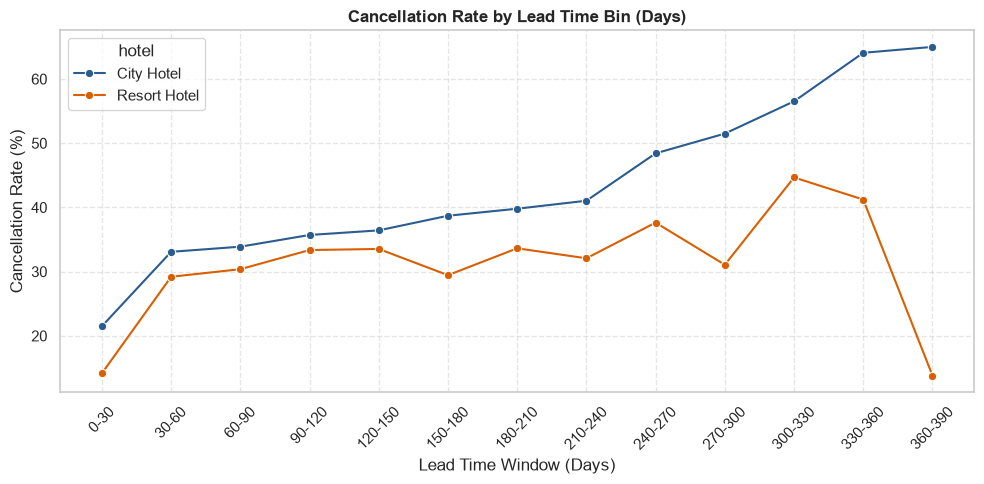

In [83]:
# Chart 5: Lead Time Bins vs Cancellation Rate
df_clean['lead_time_bin'] = pd.cut(df_clean['lead_time'], bins=range(0, 420, 30), labels=[f"{i}-{i+30}" for i in range(0, 390, 30)])
lead_df = df_clean.dropna(subset=['lead_time_bin']).groupby(['lead_time_bin', 'hotel'], observed=False)['is_canceled'].mean().reset_index()
lead_df['cancellation_rate'] = lead_df['is_canceled'] * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=lead_df, x='lead_time_bin', y='cancellation_rate', hue='hotel', marker='o', palette=['#2b5c8f', '#d95f02'])
plt.xticks(rotation=45)
plt.title("Cancellation Rate by Lead Time Bin (Days)", fontsize=12, fontweight='bold')
plt.xlabel("Lead Time Window (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart5_lead_time_cancellation.png', dpi=300)
plt.show()
plt.close()



Customer Segment Risk Profile Analysis
Business Question
Question: How do cancellation risks and pricing yields (ADR) differ across distinct customer types (Personal / Transient, Family / Transient-Party, Contract, and Business / Group), and how should marketing target each segment?

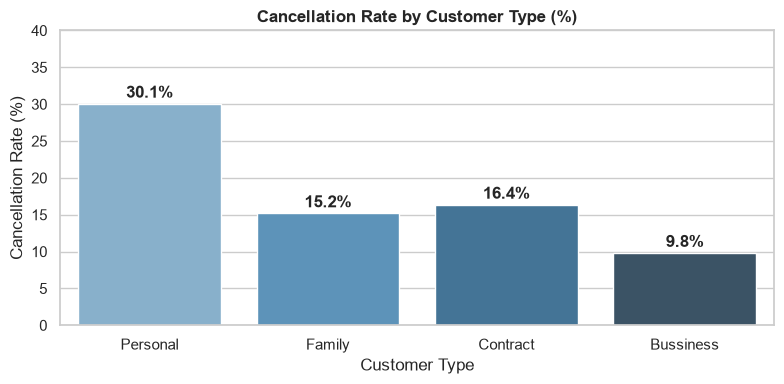

In [78]:
# Analyze Customer Types
cust_summary = df_clean.groupby('customer_type').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', lambda x: x.mean() * 100),
    avg_adr=('adr', 'mean')
).reset_index().sort_values(by='total_bookings', ascending=False)

# Visualizing Customer Type Cancellation Rates
plt.figure(figsize=(8, 4))

# Updated with hue & legend=False to fix the Seaborn FutureWarning
sns.barplot(
    data=cust_summary, 
    x='customer_type', 
    y='cancellation_rate', 
    hue='customer_type', 
    palette='Blues_d', 
    legend=False
)

plt.title('Cancellation Rate by Customer Type (%)', fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')

for index, row in cust_summary.reset_index().iterrows():
    plt.text(index, row['cancellation_rate'] + 0.8, f"{row['cancellation_rate']:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, 40)
plt.tight_layout()

# Save BEFORE plt.show() using a raw string for the file path
plt.savefig(r'E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart6_Analyze_Customer_Types.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

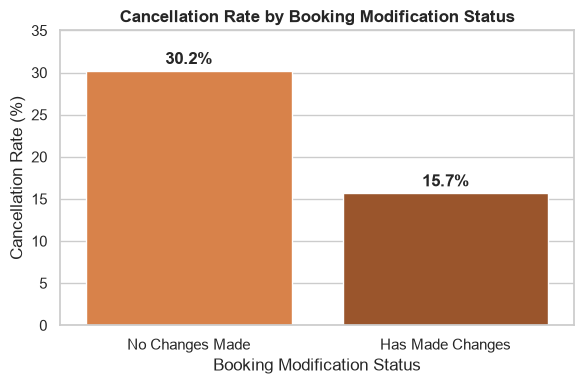

In [79]:
# Create indicator for booking changes made
df_clean['has_booking_changes'] = df_clean['booking_changes'] > 0

changes_summary = df_clean.groupby('has_booking_changes').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', lambda x: x.mean() * 100)
).reset_index()

# Visualization
plt.figure(figsize=(6, 4))
sns.barplot(
    data=changes_summary, 
    x='has_booking_changes', 
    y='cancellation_rate', 
    hue='has_booking_changes', 
    palette='Oranges_d', 
    legend=False
)

plt.title('Cancellation Rate by Booking Modification Status', fontweight='bold')
plt.xticks([0, 1], ['No Changes Made', 'Has Made Changes'])
plt.xlabel('Booking Modification Status')
plt.ylabel('Cancellation Rate (%)')

for index, row in changes_summary.iterrows():
    plt.text(index, row['cancellation_rate'] + 0.8, f"{row['cancellation_rate']:.1f}%", ha='center', fontweight='bold')

plt.ylim(0, 35)
plt.tight_layout()

# Save figure FIRST before showing/closing
plt.savefig(r'E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart7_Create_indicator_for_booking_changes_made.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

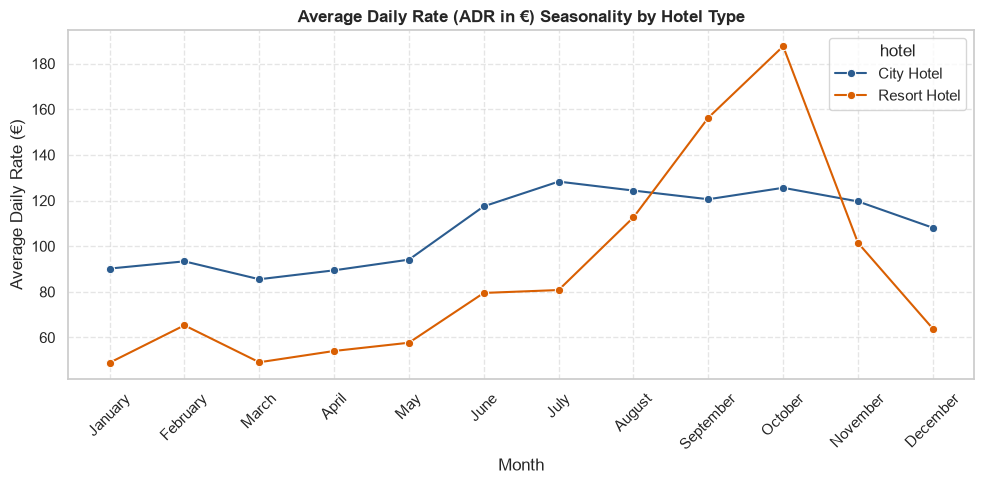

In [80]:
# Monthly ADR Trend Analysis
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
adr_monthly = df_clean.groupby(['arrival_date_month', 'hotel'], observed=False)['adr'].mean().reset_index()
adr_monthly['arrival_date_month'] = pd.Categorical(adr_monthly['arrival_date_month'], categories=months_order, ordered=True)
adr_monthly = adr_monthly.sort_values('arrival_date_month')

plt.figure(figsize=(10, 5))
sns.lineplot(data=adr_monthly, x='arrival_date_month', y='adr', hue='hotel', marker='o', palette=['#2b5c8f', '#d95f02'])
plt.xticks(rotation=45)
plt.title('Average Daily Rate (ADR in €) Seasonality by Hotel Type', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daily Rate (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure FIRST before showing/closing
plt.savefig(r'E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart8_Monthly_ADR_Trend_Analysis.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

Distribution of Market Segments
Business Question
Question: What proportion of total bookings originates from each market segment, and how dependent is the hotel on third-party intermediaries (OTAs/TAs)?

Total Third-Party (OTA/TA) Dependency: 75.36%


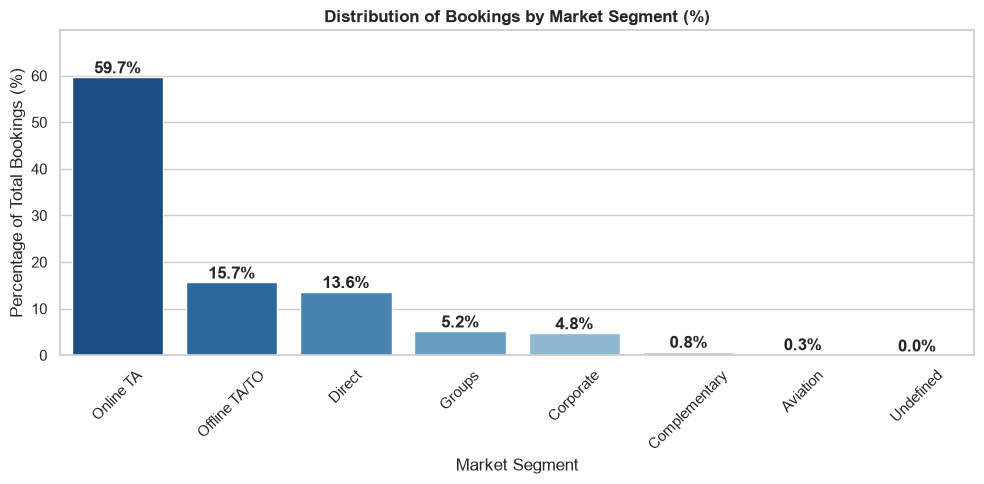

In [81]:

# 1. Calculate Market Segment Distribution
segment_summary = (
    df_clean['market_segment']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
segment_summary.columns = ['market_segment', 'percentage']

# Calculate OTA/TA Dependency (e.g., Online TA, Offline TA/TO)
ta_ota_segments = ['Online TA', 'Offline TA/TO']
ta_ota_share = segment_summary[
    segment_summary['market_segment'].isin(ta_ota_segments)
]['percentage'].sum()

print(f"Total Third-Party (OTA/TA) Dependency: {ta_ota_share:.2f}%")

# 2. Visualization
plt.figure(figsize=(10, 5))
sns.barplot(
    data=segment_summary, 
    x='market_segment', 
    y='percentage', 
    hue='market_segment', 
    palette='Blues_r', 
    legend=False
)

plt.title('Distribution of Bookings by Market Segment (%)', fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Percentage of Total Bookings (%)')
plt.xticks(rotation=45)

# Add data labels
for index, row in segment_summary.iterrows():
    plt.text(index, row['percentage'] + 0.8, f"{row['percentage']:.1f}%", ha='center', fontweight='bold')

# Adjust y-limit dynamically to make room for text labels
plt.ylim(0, segment_summary['percentage'].max() + 10)
plt.tight_layout()

# Save image FIRST before showing
plt.savefig(r'E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart9_Market_Segment_Distribution.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close()

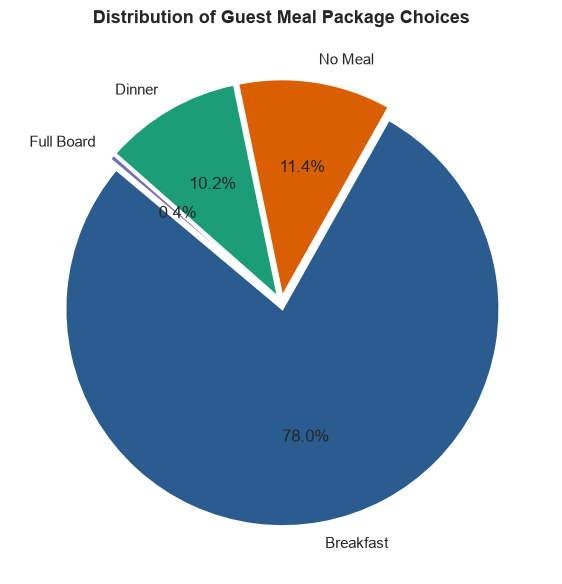

In [82]:
# Meal Plan Counts
meal_counts = df['meal'].value_counts()

# Plot Pie Chart
plt.figure(figsize=(7, 6))
colors_meal = ['#2b5c8f', '#d95f02', '#1b9e77', '#7570b3', '#e7298a'] # Added extra color to safely match unique meal categories

plt.pie(
    meal_counts, 
    labels=meal_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_meal[:len(meal_counts)],
    explode=[0.03] * len(meal_counts),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Distribution of Guest Meal Package Choices', fontsize=13, fontweight='bold')
plt.tight_layout()

# Save figure FIRST before showing/closing
plt.savefig(r'E:\INNOVEXIS PROJECT\PROJECT\Hotel Booking  Data with python\chart10_Meal_Plan_Counts.png', dpi=300, bbox_inches='tight')

plt.show()
plt.close()